<a href="https://colab.research.google.com/github/wijdanmkh-insk/EKG-debugger/blob/main/ECG_Tester.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Brief Informations About ECG**


**Cause of Baseline Wander:** patient movements, poor electrode contact, changes in electrode skin impedance. Motion frequency : 1-10Hz. This impacts ST-Segment signal distortions.

**Power-Line interference: ** proper shielding, avoiding loose connection in wires and appropiate placement of electrodes. Worked in 50-60Hz.

**EMG Noise: ** mainly distributed in 0-500Hz and concentrated in 50-150Hz.

**Conduction Duration:**
P: 0.08-0.11
QRS: 0.06-1s
PR : 0.12-0.2s
T: 0.05-0.25s
ST: 0.05-0.155s


**Recent Hurdles**


1.   The Q value for notch filter with Q = 833.3 didn't work, even it's been implemented through signal specifier, by cutting off the 50Hz value with 50.2 to 50.6 bandwidth
2.   The baseline wander is undeniable



# **Programs To Start**

**Initialize the Environment**

In [4]:
!pip install wfdb scipy matplotlib
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import butter, filtfilt, iirnotch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.0 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


In [ ]:
import glob

# Recursive search for .hea files
files = glob.glob('/content/**/*.hea', recursive=True)

if files:
    print(f"Found {len(files)} file(s):")
    for f in files:
        print(f)
else:
    print("No .hea files found. Check if your upload finished!")

Found 310 file(s):
/content/drive/MyDrive/Datasets/ecg-id/Person_49/rec_1.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_49/rec_2.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_85/rec_3.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_85/rec_1.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_85/rec_2.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_56/rec_1.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_56/rec_2.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_76/rec_3.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_76/rec_2.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_76/rec_1.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_52/rec_6.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_52/rec_10.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_52/rec_2.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_52/rec_1.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_52/rec_8.hea
/content/drive/MyDrive/Datasets/ecg-id/Person_52/rec_5.hea
/content/drive/MyDrive/Datasets/ecg-

**Import the Data and Visualize the Signals**

Text(0.5, 1.0, 'ECG Signal')

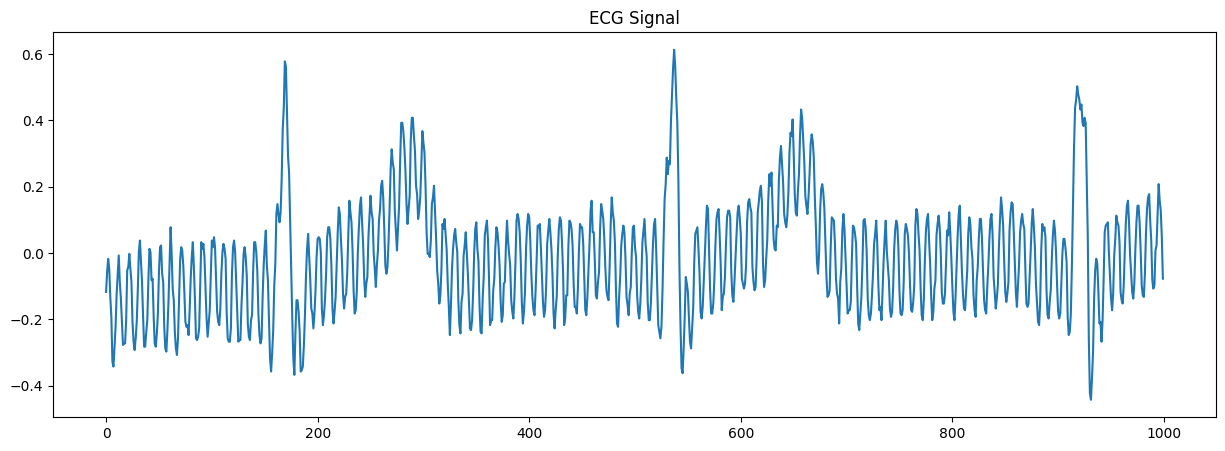

In [47]:
record = wfdb.rdrecord('/content/drive/MyDrive/Datasets/ecg-id/Person_02/rec_5')
signal = record.p_signal[:, 0]
fs = int(record.fs)
signal = signal - np.mean(signal)

plt.figure(figsize=(15,5))
plt.plot(signal[:fs*2])
plt.title("ECG Signal")

**Searching the right spectrum of the signal frequency**

Total samples: 10000
Sampling frequency: 500 Hz


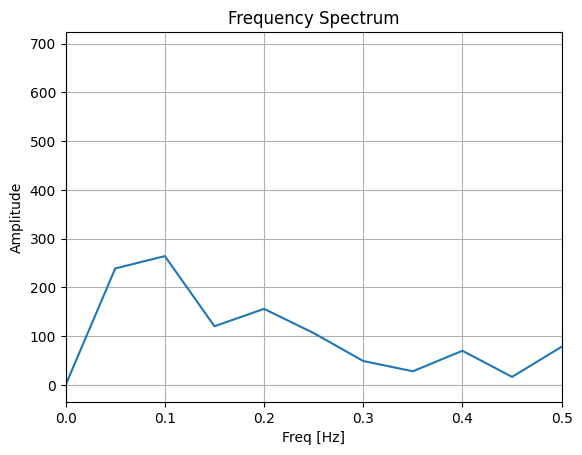

In [53]:
print(f"Total samples: {len(signal)}")
print(f"Sampling frequency: {fs} Hz")

yf = np.fft.rfft(signal)
xf = np.fft.rfftfreq(len(signal), 1/fs)

plt.plot(xf, np.abs(yf))
plt.title('Frequency Spectrum')
plt.xlim([0, 0.5])
plt.xlabel('Freq [Hz]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

**Start the Signal Filtering**

In [49]:
print(f"fs = {fs}")
print(f"signal shape = {signal.shape}")
print(f"signal dtype = {signal.dtype}")
print(f"NaNs = {np.isnan(signal).sum()}")
print(f"Plotting {fs*2} samples = {(fs*2)/fs:.1f} seconds")

fs = 500
signal shape = (10000,)
signal dtype = float64
NaNs = 0
Plotting 1000 samples = 2.0 seconds


Text(0.5, 1.0, 'Step 2: Bandpass Filtering (0.5-100Hz)')

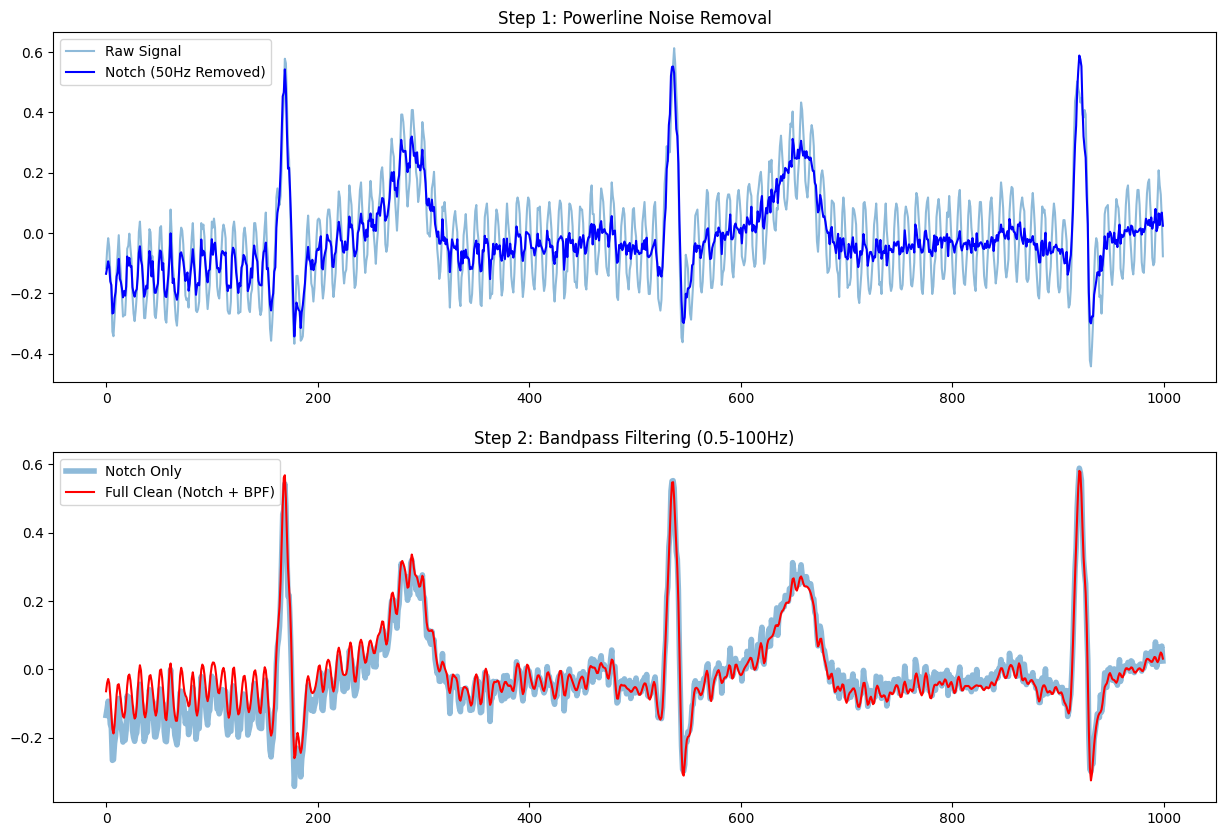

In [50]:
def butter_bpf(data, fs, lowcut=0.5, highcut=100.0, order=4):
    nyq = 0.5 * fs
    # Masukkan rentang frekuensi [bawah, atas]
    low = lowcut / nyq
    high = highcut / nyq

    # Gunakan btype='band' untuk bandpass filter
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

def notch_filter(data, freq, fs, q=125):
  nyq = 0.5*fs
  freq_norm = freq/nyq
  b, a= iirnotch(freq_norm, q)
  return filtfilt(b, a, data)

signal = signal - np.mean(signal)
filtered_notch = notch_filter(signal, 50.35, fs)
clean_ecg = butter_bpf(filtered_notch, fs, lowcut=0.5, highcut=100)

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(signal[:fs*2], label='Raw Signal', alpha=0.5)
plt.plot(filtered_notch[:fs*2], label='Notch (50Hz Removed)', color='blue')
plt.legend()
plt.title("Step 1: Powerline Noise Removal")

plt.subplot(2, 1, 2)
plt.plot(filtered_notch[:fs*2], label='Notch Only', alpha=0.5, lw=4)
plt.plot(clean_ecg[:fs*2], label='Full Clean (Notch + BPF)', color='red')
plt.legend()
plt.title("Step 2: Bandpass Filtering (0.5-100Hz)")





**Plot the Signal and Start Differentiating between Raw and Filtered**

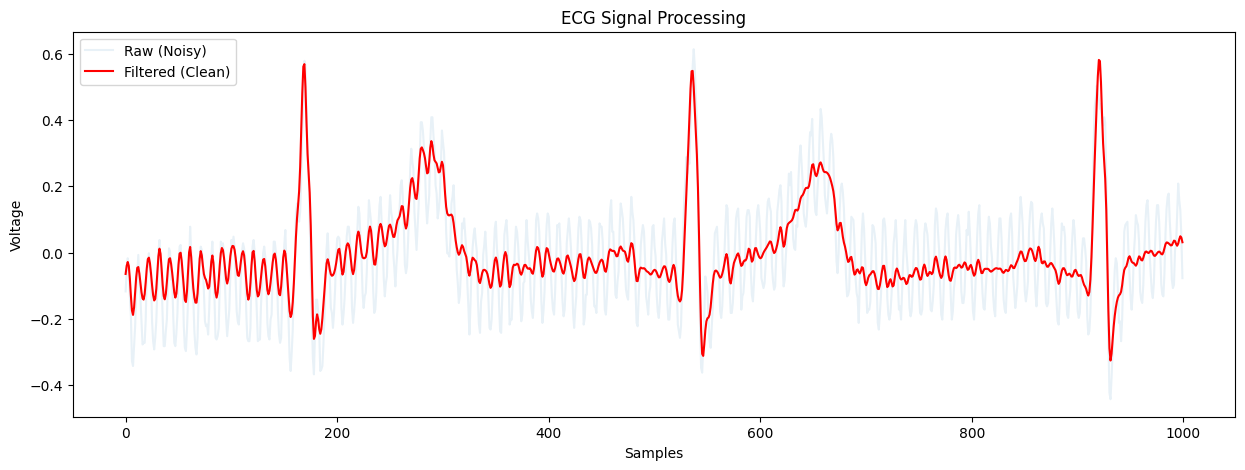

Total samples: 10000
Sampling frequency: 500 Hz


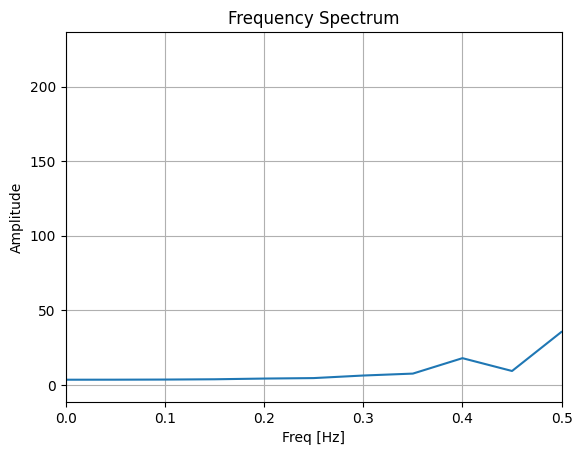

In [51]:
plt.figure(figsize=(15, 5))
plt.plot(signal[:fs*2], label='Raw (Noisy)', alpha=0.1)
plt.plot(clean_ecg[:fs*2], label='Filtered (Clean)', color='red')
plt.legend()
plt.title("ECG Signal Processing")
plt.xlabel("Samples")
plt.ylabel("Voltage")
plt.show()

print(f"Total samples: {len(signal)}")
print(f"Sampling frequency: {fs} Hz")

yf = np.fft.rfft(clean_ecg)
xf = np.fft.rfftfreq(len(clean_ecg), 1/fs)

plt.plot(xf, np.abs(yf))
plt.title('Frequency Spectrum')
plt.xlim([0, 0.5])
plt.xlabel('Freq [Hz]')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()